Shape: (11162, 17)
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


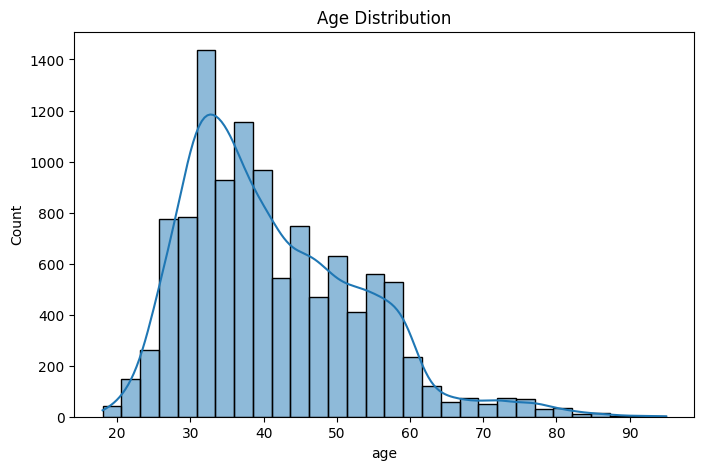

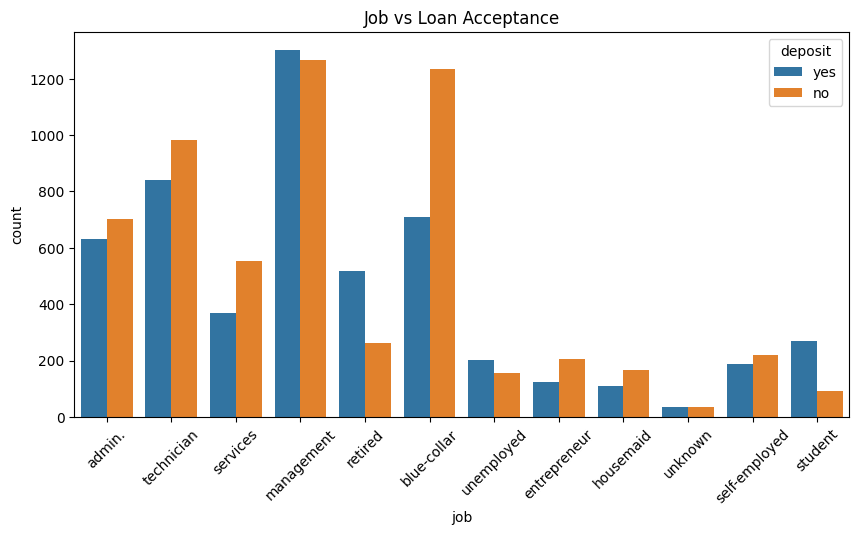

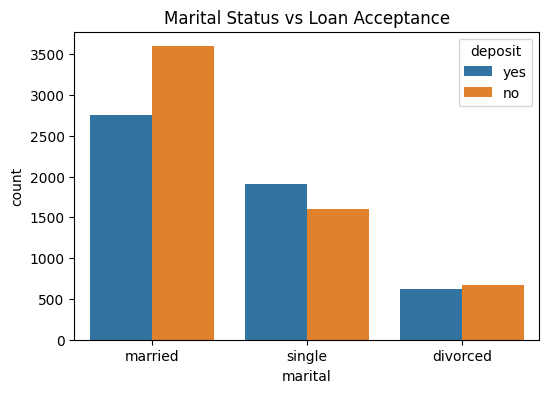

Logistic Regression Accuracy: 0.7899686520376176
Confusion Matrix:
 [[955 211]
 [258 809]]


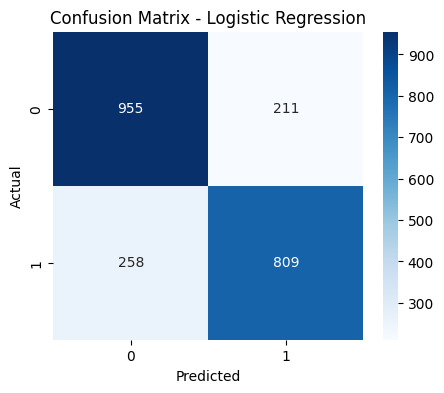


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233

Decision Tree Accuracy: 0.7630989699955217

Acceptance Rate by Job:

deposit              no       yes
job                              
admin.         0.526987  0.473013
blue-collar    0.635802  0.364198
entrepreneur   0.625000  0.375000
housemaid      0.602190  0.397810
management     0.492985  0.507015
retired        0.336761  0.663239
self-employed  0.538272  0.461728
services       0.600217  0.399783
student        0.252778  0.747222
technician     0.539221  0.460779
unemployed     0.434174  0.565826
unknown        0.514286  0.485714

Acceptance Rate by Marital Status:

deposit         no       yes
marital                     
divorced

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv("bank.csv", sep=",")   # change filename if bank-full.csv
print("Shape:", df.shape)
print(df.head())

# Basic EDA
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x="job", hue="deposit", data=df)
plt.title("Job vs Loan Acceptance")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="marital", hue="deposit", data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

# Encoding
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Decision Tree model (optional)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

# Business Insights (Acceptance Rates)
df_original = pd.read_csv("bank.csv", sep=",")

print("\nAcceptance Rate by Job:\n")
print(df_original.groupby("job")["deposit"].value_counts(normalize=True).unstack())

print("\nAcceptance Rate by Marital Status:\n")
print(df_original.groupby("marital")["deposit"].value_counts(normalize=True).unstack())